In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 6,                # reduced for small figure
    "axes.labelsize": 6,
    "axes.titlesize": 6,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "axes.linewidth": 0.5,
    "lines.linewidth": 0.6,
    "legend.fontsize": 5.5,
    "legend.title_fontsize": 5.5,
    "xtick.major.size": 2,
    "ytick.major.size": 2,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "pdf.fonttype": 42,            # ensures editable text in Illustrator
    "ps.fonttype": 42
})

def make_fixed_axis(axis_size=1.25, label_space=0.15):
    """Create figure with a fixed physical data-area size."""
    figsize = (axis_size + label_space, axis_size + label_space)
    fig = plt.figure(figsize=figsize, constrained_layout=True)
    gs = fig.add_gridspec(1, 1)
    ax = fig.add_subplot(gs[0, 0])
    ax.set_box_aspect(1)  # ensures square data region
    return fig, ax

In [4]:
def compute_mean_fraction(data_array):
    A = data_array[0]
    B = data_array[1]
    total = A + B
    with np.errstate(divide='ignore', invalid='ignore'):
        frac = np.where(total == 0, np.nan, A / total)
    return np.nanmean(frac), np.nanstd(frac)



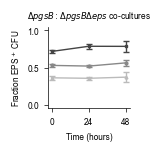

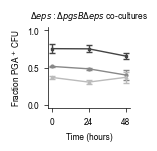

In [8]:


df_0 = pd.read_excel(r"C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0810\F0810 CFU Raw Data Final.xlsx", sheet_name = "Day 0", skiprows = 2)
df_0 = df_0.iloc[:3, :]

df_1 = pd.read_excel(r"C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0810\F0810 CFU Raw Data Final.xlsx", sheet_name = "Day 1", skiprows = 2)
df_1 = df_1.iloc[:3, :]

df_2 = pd.read_excel(r"C:\Users\ayantis\Desktop\PhD\Research\Experimental Data\F0810\F0810 CFU Raw Data Final.xlsx", sheet_name = "Day 2", skiprows = 2)
df_2 = df_2.iloc[:3, :]

DPGA_DPGADEPS_75_25_0 = np.array([df_0.loc[:,"PGA-"], df_0.loc[:,"PGA-EPS-"]])/ 25
DPGA_DPGADEPS_50_50_0 = np.array([df_0.loc[:,"PGA-.1"], df_0.loc[:,"PGA-EPS-.1"]])/ 25
DPGA_DPGADEPS_25_75_0 = np.array([df_0.loc[:,"PGA-.2"], df_0.loc[:,"PGA-EPS-.2"]])/ 25


DEPS_DPGADEPS_75_25_0 = np.array([df_0.loc[:,"EPS-"], df_0.loc[:,"PGA-EPS-.4"]])/ 25
DEPS_DPGADEPS_50_50_0 = np.array([df_0.loc[:,"EPS-.1"], df_0.loc[:,"PGA-EPS-.5"]])/ 25
DEPS_DPGADEPS_25_75_0 = np.array([df_0.loc[:,"EPS-.2"], df_0.loc[:,"PGA-EPS-.6"]])/ 25

DPGA_DPGADEPS_75_25_1 = np.array([df_1.loc[:,"PGA-"], df_1.loc[:,"PGA-EPS-"]])
DPGA_DPGADEPS_50_50_1 = np.array([df_1.loc[:,"PGA-.1"], df_1.loc[:,"PGA-EPS-.1"]])
DPGA_DPGADEPS_25_75_1 = np.array([df_1.loc[:,"PGA-.2"], df_1.loc[:,"PGA-EPS-.2"]])


DEPS_DPGADEPS_75_25_1 = np.array([df_1.loc[:,"EPS-"], df_1.loc[:,"PGA-EPS-.4"]])
DEPS_DPGADEPS_50_50_1 = np.array([df_1.loc[:,"EPS-.1"], df_1.loc[:,"PGA-EPS-.5"]])
DEPS_DPGADEPS_25_75_1 = np.array([df_1.loc[:,"EPS-.2"], df_1.loc[:,"PGA-EPS-.6"]])

DPGA_DPGADEPS_75_25_2 = np.array([df_2.loc[:,"PGA-"], df_2.loc[:,"PGA-EPS-"]])
DPGA_DPGADEPS_50_50_2 = np.array([df_2.loc[:,"PGA-.1"], df_2.loc[:,"PGA-EPS-.1"]])
DPGA_DPGADEPS_25_75_2 = np.array([df_2.loc[:,"PGA-.2"], df_2.loc[:,"PGA-EPS-.2"]])


DEPS_DPGADEPS_75_25_2 = np.array([df_2.loc[:,"EPS-"], df_2.loc[:,"PGA-EPS-.4"]])
DEPS_DPGADEPS_50_50_2 = np.array([df_2.loc[:,"EPS-.1"], df_2.loc[:,"PGA-EPS-.5"]])
DEPS_DPGADEPS_25_75_2 = np.array([df_2.loc[:,"EPS-.2"], df_2.loc[:,"PGA-EPS-.6"]])

days = [0, 24, 48]
#$\Delta pgsB : \Delta pgsB \Delta eps$ co-cultures
dpga_sets = [
    ("0.75:0.25", [DPGA_DPGADEPS_75_25_0, DPGA_DPGADEPS_75_25_1, DPGA_DPGADEPS_75_25_2]),
    ("0.50:0.50", [DPGA_DPGADEPS_50_50_0, DPGA_DPGADEPS_50_50_1, DPGA_DPGADEPS_50_50_2]),
    ("0.25:0.75", [DPGA_DPGADEPS_25_75_0, DPGA_DPGADEPS_25_75_1, DPGA_DPGADEPS_25_75_2]),
]

fig, ax = make_fixed_axis()

palette = ["#444444", "#888888",  "#BBBBBB"]
markers = ["s", "o", "^"]  # square, circle, triangle

for (label, data_list), color, marker in zip(dpga_sets, palette, markers):
    means, stds = zip(*[compute_mean_fraction(data) for data in data_list])
    ax.errorbar(
        days, means, yerr=stds,
        marker=marker, elinewidth=1,capsize=2,color = color,markersize=2,linewidth=1)
ax.set_title(r"$\Delta pgsB : \Delta pgsB \Delta eps$ co-cultures")
ax.set_xlabel("Time (hours)")
ax.set_ylabel(r"Fraction EPS$^+$ CFU")
ax.set_xticks(days)
ax.set_ylim(-0.05, 1.05)
ax.tick_params(axis='both', width=0.5, length=3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

#$\Delta eps : \Delta pgsB \Delta eps$ co-cultures
deps_sets = [
    ("0.75:0.25", [DEPS_DPGADEPS_75_25_0, DEPS_DPGADEPS_75_25_1, DEPS_DPGADEPS_75_25_2]),
    ("0.50:0.50", [DEPS_DPGADEPS_50_50_0, DEPS_DPGADEPS_50_50_1, DEPS_DPGADEPS_50_50_2]),
    ("0.25:0.75", [DEPS_DPGADEPS_25_75_0, DEPS_DPGADEPS_25_75_1, DEPS_DPGADEPS_25_75_2])
]
fig, ax = make_fixed_axis()

for (label, data_list), color, marker in zip(deps_sets, palette, markers):
    means, stds = zip(*[compute_mean_fraction(data) for data in data_list])
    ax.errorbar(
        days, means, yerr=stds,
        marker=marker, elinewidth=1,capsize=2,color = color,markersize=2,linewidth=1)

    ax.set_title(r"$\Delta eps : \Delta pgsB \Delta eps$ co-cultures")
ax.set_xlabel("Time (hours)")
ax.set_ylabel(r"Fraction PGA$^+$ CFU")
ax.set_xticks(days)
ax.set_ylim(-0.05, 1.05)
ax.tick_params(axis='both', width=0.5, length=3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()
